# Import Libraries

In [1]:
# Standard libraries
import os  # OS operations
import shutil  # File operations

# Data handling
import pandas as pd  # DataFrames
import numpy as np  # Numerical ops

# Visualization
import matplotlib.pyplot as plt  # Plots
import seaborn as sns  # Statistical plots

# KaggleHub for downloading datasets/models
import kagglehub

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Computer vision
import cv2  # Image processing

# Scikit-learn utilities and metrics
from sklearn.utils import compute_class_weight  # Compute class weights for imbalanced data
from sklearn.metrics import roc_curve, auc  # ROC & AUC
from sklearn.metrics import confusion_matrix  # Confusion matrix
from sklearn.preprocessing import label_binarize  # Binarize labels for multi-class ROC
from sklearn.metrics import precision_recall_curve, average_precision_score  # Precision-recall metrics
from sklearn.metrics import classification_report

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Data augmentation
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D  # Core layers
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D  # Extra layers
from tensorflow.keras.models import Model, Sequential  # Model architectures
from tensorflow.keras.optimizers import Adam  # Optimizer

2025-10-02 19:33:50.217872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759433630.400144      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759433630.455853      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load Dataset

In [2]:
data = "/kaggle/input/AugmentedAlzheimerDataset"
data

'/kaggle/input/AugmentedAlzheimerDataset'

In [3]:
# Function to count images in each directory
def count_images_in_dirs(base_dir):
    dir_counts = {}
    for root, _, files in os.walk(base_dir):
        # Filter out non-image files if necessary, here we assume all are images
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if image_files: # Only add directory if it contains images
            dir_counts[root] = len(image_files)
    return dir_counts

count_images_in_dirs(data)

{'/kaggle/input/AugmentedAlzheimerDataset/ModerateDemented': 6464,
 '/kaggle/input/AugmentedAlzheimerDataset/NonDemented': 9600,
 '/kaggle/input/AugmentedAlzheimerDataset/VeryMildDemented': 8960,
 '/kaggle/input/AugmentedAlzheimerDataset/MildDemented': 8960}

# Data Spliting to (Train - Validation - Test)

In [4]:
# Input and Output Paths
base_dir = '/kaggle/working/'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Create output directories
for split_dir in [train_dir, validation_dir, test_dir]:
    os.makedirs(split_dir, exist_ok=True)

# Categories from your dataset
categories = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Split ratios
train_ratio = 0.8
validation_ratio = 0.1
test_ratio = 0.1

# Split and copy
for category in categories:
    category_path = os.path.join(data, category)
    image_files = os.listdir(category_path)
    np.random.shuffle(image_files)

    num_images = len(image_files)
    num_train = int(train_ratio * num_images)
    num_val = int(validation_ratio * num_images)

    train_files = image_files[:num_train]
    val_files = image_files[num_train:num_train + num_val]
    test_files = image_files[num_train + num_val:]

    # Copy helper
    def copy_files(file_list, dest_dir):
        dest_category_dir = os.path.join(dest_dir, category)
        os.makedirs(dest_category_dir, exist_ok=True)
        for file in file_list:
            src_path = os.path.join(category_path, file)
            dst_path = os.path.join(dest_category_dir, file)
            shutil.copy(src_path, dst_path)

    copy_files(train_files, train_dir)
    copy_files(val_files, validation_dir)
    copy_files(test_files, test_dir)

print("Data split completed!")

Data split completed!


# Count images in each directory

In [5]:
# Function to count images in each directory
def count_images_in_dirs(base_dir):
    dir_counts = {}
    for root, _, files in os.walk(base_dir):
        # Filter out non-image files if necessary, here we assume all are images
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if image_files: # Only add directory if it contains images
            dir_counts[root] = len(image_files)
    return dir_counts

# Check image counts in train, validation, and test directories
print("Image counts in Train Directory:")
train_counts = count_images_in_dirs(train_dir)
for directory, count in train_counts.items():
    print(f"  {directory}: {count} images")

print("\nImage counts in Validation Directory:")
validation_counts = count_images_in_dirs(validation_dir)
for directory, count in validation_counts.items():
    print(f"  {directory}: {count} images")

print("\nImage counts in Test Directory:")
test_counts = count_images_in_dirs(test_dir)
for directory, count in test_counts.items():
    print(f"  {directory}: {count} images")

# Optional: Print total counts per split
total_train = sum(train_counts.values())
total_validation = sum(validation_counts.values())
total_test = sum(test_counts.values())

print(f"\nTotal images in train set: {total_train}")
print(f"Total images in validation set: {total_validation}")
print(f"Total images in test set: {total_test}")

Image counts in Train Directory:
  /kaggle/working/train/NonDemented: 7680 images
  /kaggle/working/train/VeryMildDemented: 7168 images
  /kaggle/working/train/MildDemented: 7168 images
  /kaggle/working/train/ModerateDemented: 5171 images

Image counts in Validation Directory:
  /kaggle/working/validation/NonDemented: 960 images
  /kaggle/working/validation/VeryMildDemented: 896 images
  /kaggle/working/validation/MildDemented: 896 images
  /kaggle/working/validation/ModerateDemented: 646 images

Image counts in Test Directory:
  /kaggle/working/test/NonDemented: 960 images
  /kaggle/working/test/VeryMildDemented: 896 images
  /kaggle/working/test/MildDemented: 896 images
  /kaggle/working/test/ModerateDemented: 647 images

Total images in train set: 27187
Total images in validation set: 3398
Total images in test set: 3399


# Display sample images

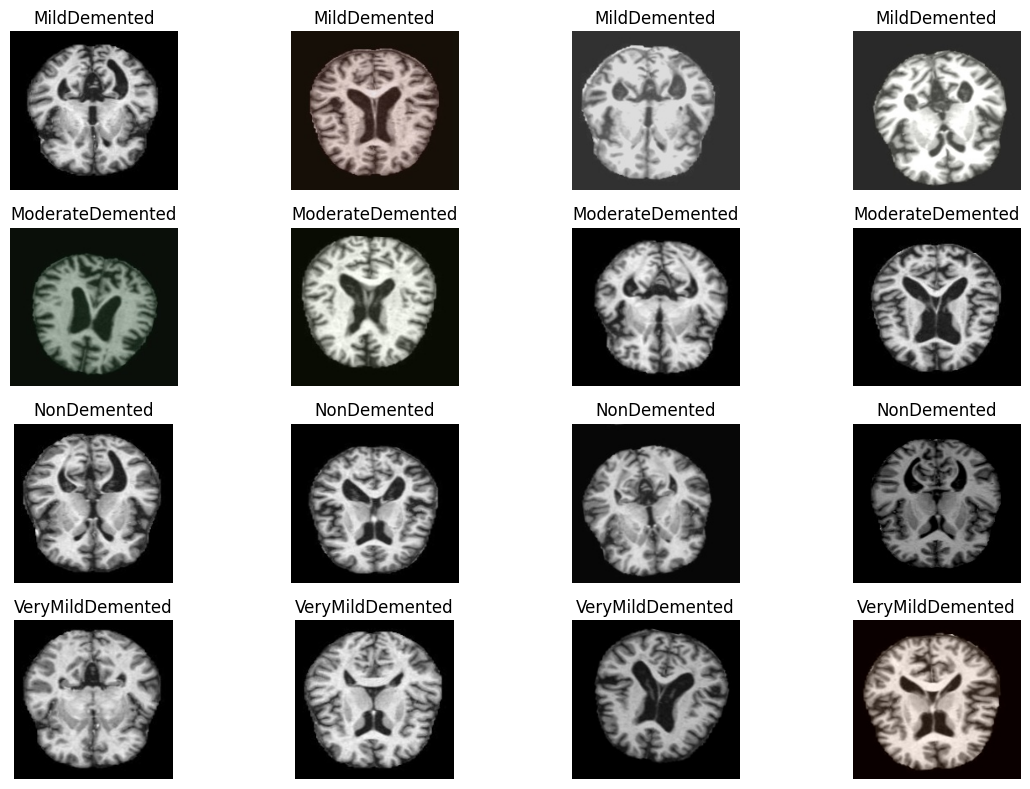

In [6]:
# Function to display sample images
def display_sample_images(directory, num_images=4):
    plt.figure(figsize=(12, 8))
    i = 0
    for category in categories:
        category_path = os.path.join(directory, category)
        image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))][:num_images] # Take up to num_images

        for img_file in image_files:
            img_path = os.path.join(category_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

            plt.subplot(len(categories), num_images, i + 1)
            plt.imshow(img)
            plt.title(f"{category}")
            plt.axis('off')
            i += 1
            if i >= len(categories) * num_images: # Stop if we have enough images
              break
        if i >= len(categories) * num_images: # Stop if we have enough images
          break

    plt.tight_layout()
    plt.show()

# Display sample images
display_sample_images(train_dir, num_images=4)

# Image Data Generator

In [7]:
# Image Data Generator
datagen = ImageDataGenerator(rescale=1./255)

# Create generators from the split directories
train_generator = datagen.flow_from_directory(
    train_dir,  # Use the training directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,  # Use the validation directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,  # Use the test directory
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep order for evaluation metrics
)


Found 27187 images belonging to 4 classes.
Found 3398 images belonging to 4 classes.
Found 3399 images belonging to 4 classes.


# CNN Model

## Build Model

In [8]:
# Clear previous models
tf.keras.backend.clear_session()

# Build the improved CNN
model = Sequential([

    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Flatten and Dense Layers
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 output classes
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

I0000 00:00:1759433863.743637      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,008,804 (19.11 MB)

 Trainable params: 5,007,844 (19.10 MB)

 Non-trainable params: 960 (3.75 KB)

## Callbacks

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

## Model Training

In [10]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

Epoch 1/30


I0000 00:00:1759433870.557291      81 service.cc:148] XLA service 0x7e72f8018e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759433870.558108      81 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759433871.153861      81 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/850 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.2763 - loss: 2.1847

I0000 00:00:1759433878.027538      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


850/850 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.5254 - loss: 1.1398 - val_accuracy: 0.6574 - val_loss: 0.8205
Epoch 2/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.7383 - loss: 0.6132 - val_accuracy: 0.8170 - val_loss: 0.4524
Epoch 3/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8174 - loss: 0.4499 - val_accuracy: 0.8505 - val_loss: 0.3696
Epoch 4/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8705 - loss: 0.3358 - val_accuracy: 0.8788 - val_loss: 0.3095
Epoch 5/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8996 - loss: 0.2668 - val_accuracy: 0.9129 - val_loss: 0.2397
Epoch 6/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9202 - loss: 0.2141 - val_accuracy: 0.9241 - val_loss: 0.1988
Epoch 7/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9364 - loss: 0.1777 - val_accuracy: 0.9182 - val_loss: 0.2099
Epoch 8/30
850/850 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9456 - loss: 0.1446 - val_accurac

## Model Evaluation

In [11]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9539 - loss: 0.1295
Test Accuracy: 95.00%
Test Loss: 0.1450


# Model Prediction and Testing

## Training and Vaildataion

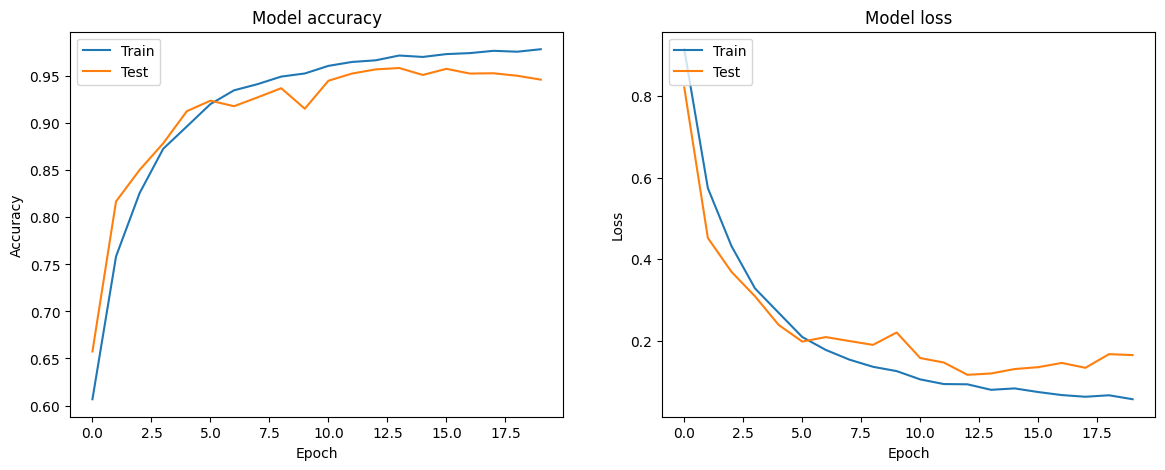

In [12]:
fig = plt.figure(figsize=(14, 5))

# Plot training & validation accuracy values
fig.add_subplot(121)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
fig.add_subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

## Make Prediction

In [13]:
# Get true labels and predicted probabilities for the test set
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)

# Get predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Get class names
class_names = list(test_generator.class_indices.keys())

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


## Classification Report

In [14]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                   precision    recall  f1-score   support

    MildDemented       0.98      0.95      0.96       896
ModerateDemented       1.00      1.00      1.00       647
     NonDemented       0.94      0.93      0.94       960
VeryMildDemented       0.90      0.94      0.92       896

        accuracy                           0.95      3399
       macro avg       0.95      0.95      0.95      3399
    weighted avg       0.95      0.95      0.95      3399



## Confusion Matrix

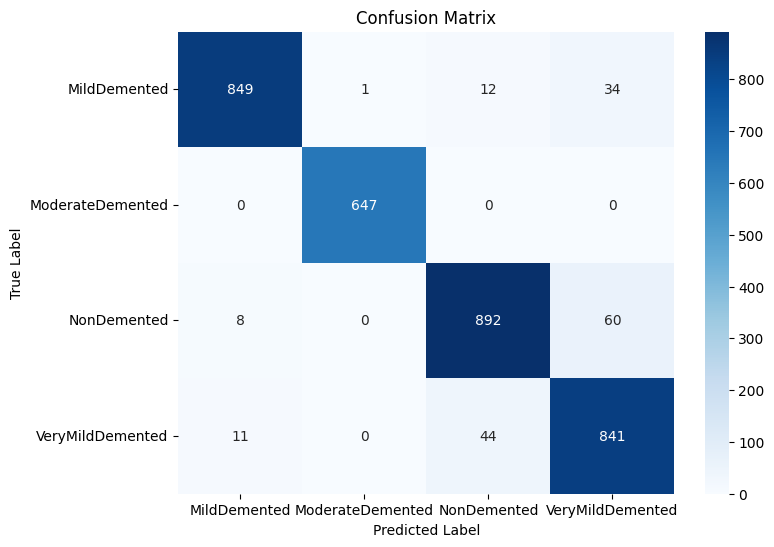

In [15]:
# Get predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Get class names
class_names = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

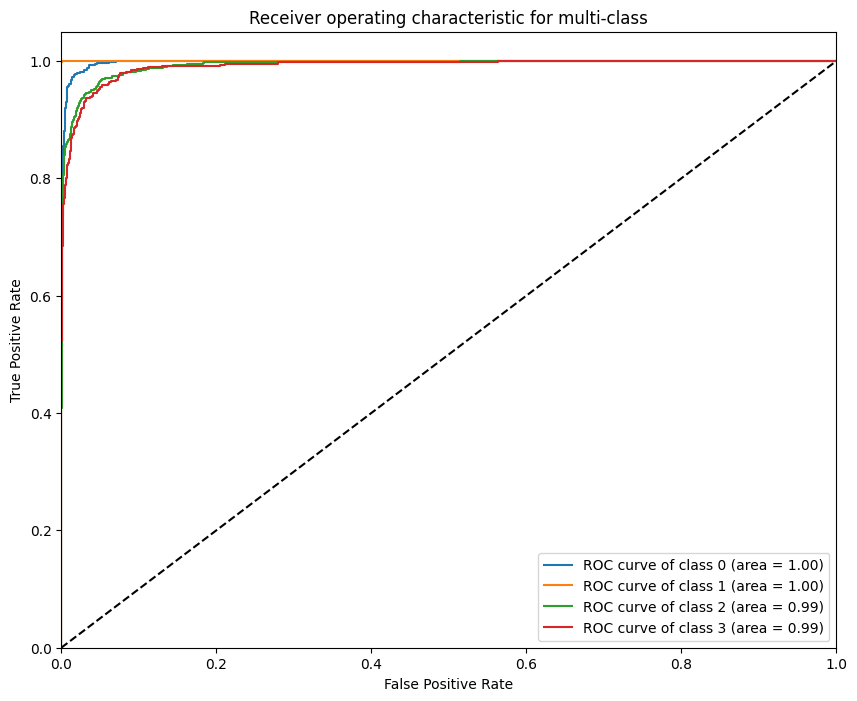

In [16]:
# Binarize the true labels for multi-class ROC
y_true_binarized = label_binarize(y_true, classes=np.arange(test_generator.num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(test_generator.num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(test_generator.num_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for multi-class')
plt.legend(loc="lower right")
plt.show()

## Precision-Recall Curve

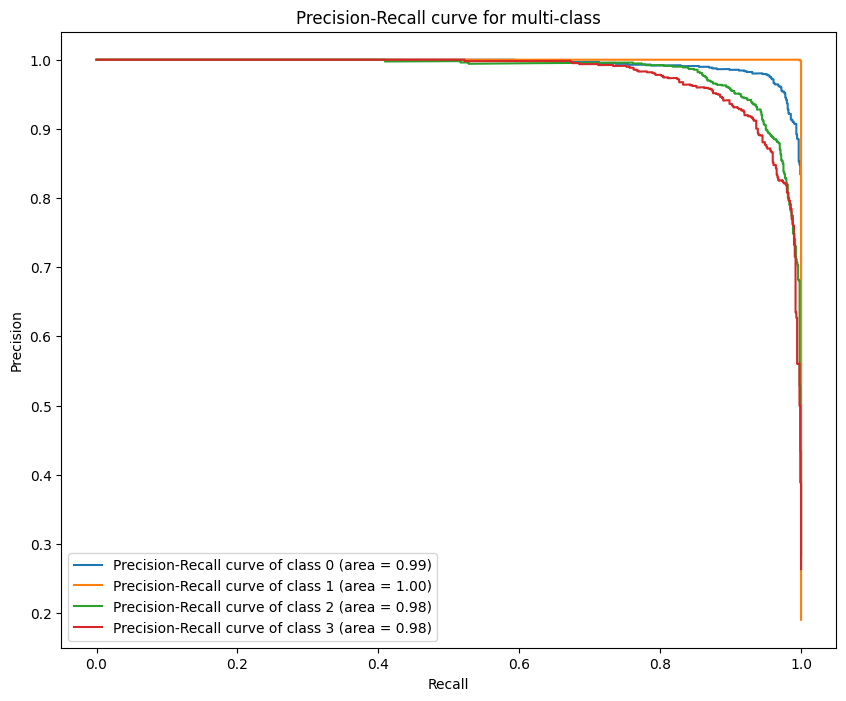

In [17]:
# Binarize the true labels for multi-class Precision-Recall
y_true_binarized = label_binarize(y_true, classes=np.arange(test_generator.num_classes))

# Compute Precision-Recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(test_generator.num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    average_precision[i] = average_precision_score(y_true_binarized[:, i], y_pred_prob[:, i])

# Plot the Precision-Recall curves
plt.figure(figsize=(10, 8))
for i in range(test_generator.num_classes):
    plt.plot(recall[i], precision[i], label='Precision-Recall curve of class {0} (area = {1:0.2f})'.format(i, average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for multi-class')
plt.legend(loc="lower left")
plt.show()

## Testing on one image from each class



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


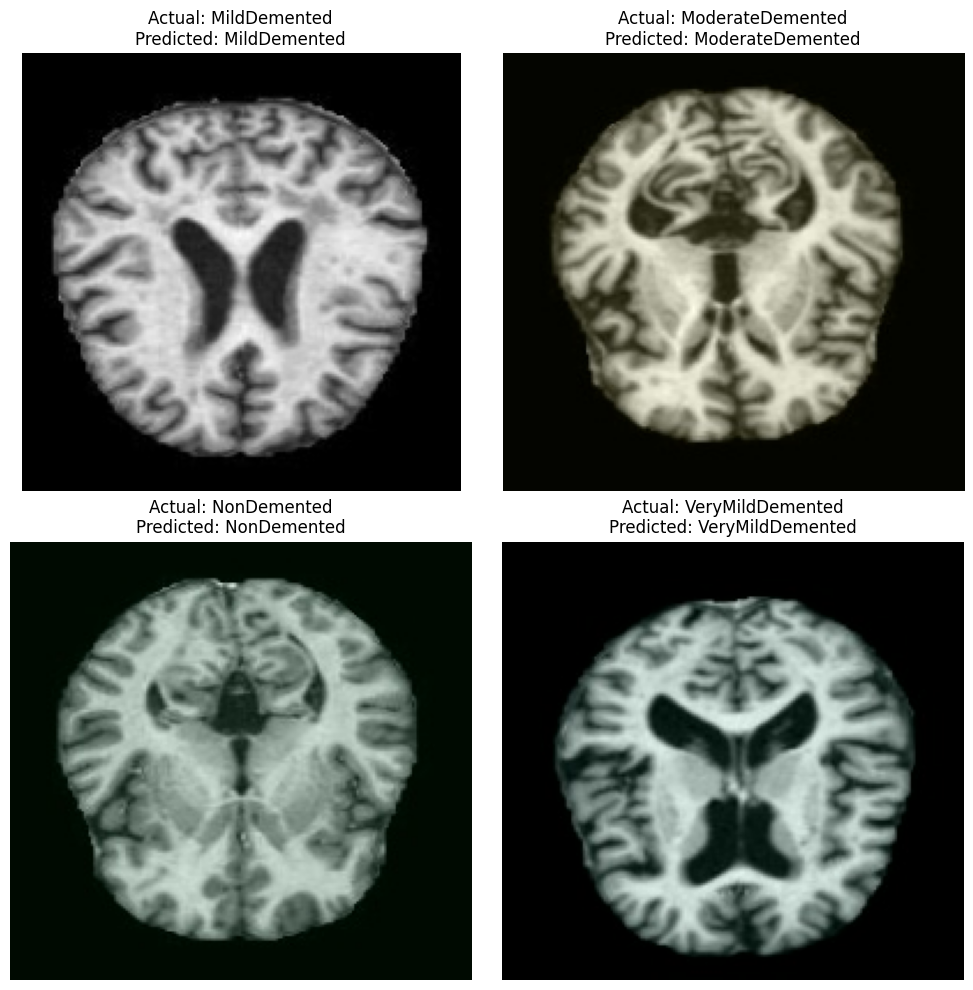

In [18]:
# Make test predictions and visualize one image per class
# Get one image path for each class from the test set
test_image_paths = {}
for category in categories:
    category_path = os.path.join(test_dir, category)
    # List all files in the category directory
    files_in_category = os.listdir(category_path)
    # Filter out directories if any
    image_files = [f for f in files_in_category if os.path.isfile(os.path.join(category_path, f))]
    if image_files:
        # Pick the first image found (or you could pick randomly)
        test_image_paths[category] = os.path.join(category_path, image_files[0])
    else:
        print(f"No images found in {category_path}")


plt.figure(figsize=(10, 10))

# Predict and display one image from each class
for i, (category, img_path) in enumerate(test_image_paths.items()):
    if img_path:
        # Load and preprocess the image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
        img_resized = cv2.resize(img, (128, 128))
        img_array = np.expand_dims(img_resized, axis=0) / 255.0 # Add batch dimension and normalize

        # Make prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        predicted_class_name = categories[predicted_class_index]

        # Display the image and prediction
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(f"Actual: {category}\nPredicted: {predicted_class_name}")
        plt.axis('off')
    else:
        plt.subplot(2, 2, i + 1)
        plt.title(f"Actual: {category}\nNo image available")
        plt.axis('off')

plt.tight_layout()
plt.show()

# Save Model

In [19]:
# Add the saving part after model evaluation
model.save(f'alzheimer_detection_model_acc_{accuracy * 100:.2f}%.keras')